<a href="https://colab.research.google.com/github/LAVOTSIRC/simulasi-ddos/blob/Google_Collab/Analisis_model_deteksi_DDoS_dengan_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. IMPORT LIBRARY

In [212]:
print("=" * 65)
print("  TAHAP 1: IMPORT LIBRARY")
print("=" * 65)

import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import joblib

from scipy import stats

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif  # [FIX-6] RFE dihapus
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
RANDOM_STATE = 42

print("✅ Semua library berhasil di-import!\n")

  TAHAP 1: IMPORT LIBRARY
✅ Semua library berhasil di-import!



# 2. LOAD DATASET

In [213]:
print("=" * 65)
print("  TAHAP 2: LOAD DATASET")
print("=" * 65)

print("Mengunduh dataset dari Kaggle...")
path = kagglehub.dataset_download("aikenkazin/ddos-sdn-dataset")
csv_files = glob.glob(os.path.join(path, "*.csv"))

if not csv_files:
    raise FileNotFoundError("❌ Tidak ada file CSV ditemukan di path dataset!")

df = pd.read_csv(csv_files[0])

print(f"✅ Dataset berhasil di-load!")
print(f"   Jumlah baris  : {df.shape[0]:,}")
print(f"   Jumlah kolom  : {df.shape[1]}")
print(f"\n--- 5 Baris Pertama ---")
print(df.head())
print(f"\n--- Tipe Data ---")
print(df.dtypes)
print(f"\n--- Info Dataset ---")
df.info()


  TAHAP 2: LOAD DATASET
Mengunduh dataset dari Kaggle...
Using Colab cache for faster access to the 'ddos-sdn-dataset' dataset.
✅ Dataset berhasil di-load!
   Jumlah baris  : 104,345
   Jumlah kolom  : 23

--- 5 Baris Pertama ---
      dt  switch       src       dst  pktcount  bytecount  dur   dur_nsec  \
0  11425       1  10.0.0.1  10.0.0.8     45304   48294064  100  716000000   
1  11605       1  10.0.0.1  10.0.0.8    126395  134737070  280  734000000   
2  11425       1  10.0.0.2  10.0.0.8     90333   96294978  200  744000000   
3  11425       1  10.0.0.2  10.0.0.8     90333   96294978  200  744000000   
4  11425       1  10.0.0.2  10.0.0.8     90333   96294978  200  744000000   

        tot_dur  flows  ...  pktrate  Pairflow  Protocol  port_no   tx_bytes  \
0  1.010000e+11      3  ...      451         0       UDP        3  143928631   
1  2.810000e+11      2  ...      451         0       UDP        4       3842   
2  2.010000e+11      3  ...      451         0       UDP        1  

# 3. EXPLORATORY DATA ANALYSIS (EDA)

## 3a. Distribusi Kelas


--- Distribusi Kelas Label ---
       Jumlah  Persentase (%)
label                        
0       63561           60.91
1       40784           39.09


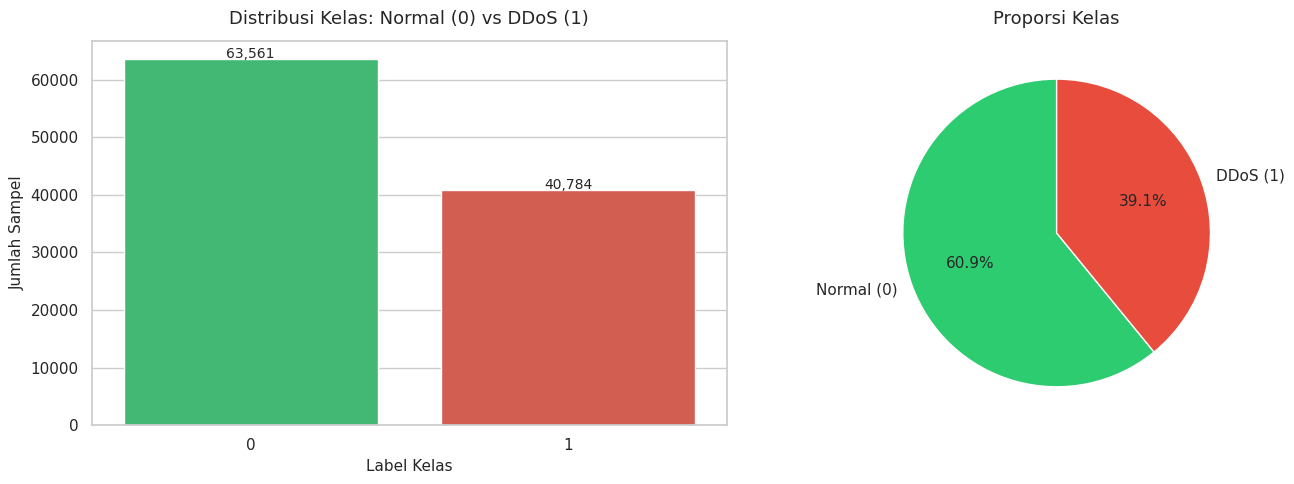

✅ Plot distribusi kelas tersimpan.


In [214]:
print("\n--- Distribusi Kelas Label ---")
distribusi = df['label'].value_counts()
persen     = df['label'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Jumlah': distribusi, 'Persentase (%)': persen.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart distribusi kelas
ax = sns.countplot(data=df, x='label',
                   palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Distribusi Kelas: Normal (0) vs DDoS (1)',
                   fontsize=13, pad=12)
axes[0].set_xlabel('Label Kelas', fontsize=11)
axes[0].set_ylabel('Jumlah Sampel', fontsize=11)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height() + 200),
                ha='center', fontsize=10)

# Pie chart persentase
axes[1].pie(distribusi, labels=['Normal (0)', 'DDoS (1)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proporsi Kelas', fontsize=13, pad=12)

plt.tight_layout()
plt.savefig('eda_distribusi_kelas.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot distribusi kelas tersimpan.")

## 3b. Statistik Deskriptif

In [215]:
print("\n--- Statistik Deskriptif Fitur Numerik ---")
print(df.describe().round(3).T)


--- Statistik Deskriptif Fitur Numerik ---
                count          mean           std          min           25%  \
dt           104345.0  1.792751e+04  1.197764e+04       2488.0  7.098000e+03   
switch       104345.0  4.214000e+00  1.956000e+00          1.0  3.000000e+00   
pktcount     104345.0  5.286096e+04  5.202324e+04          0.0  8.080000e+02   
bytecount    104345.0  3.818660e+07  4.877748e+07          0.0  7.957600e+04   
dur          104345.0  3.214970e+02  2.835180e+02          0.0  1.270000e+02   
dur_nsec     104345.0  4.613880e+08  2.770019e+08          0.0  2.340000e+08   
tot_dur      104345.0  3.218865e+11  2.834029e+11          0.0  1.270000e+11   
flows        104345.0  5.654000e+00  2.950000e+00          2.0  3.000000e+00   
packetins    104345.0  5.200383e+03  5.257001e+03          4.0  1.943000e+03   
pktperflow   104345.0  6.381715e+03  7.404778e+03    -130933.0  2.900000e+01   
byteperflow  104345.0  4.716150e+06  7.560116e+06 -146442594.0  2.842000e+03

## 3c. Distribusi Tiap Fitur Numerik


Jumlah fitur numerik (selain label): 19


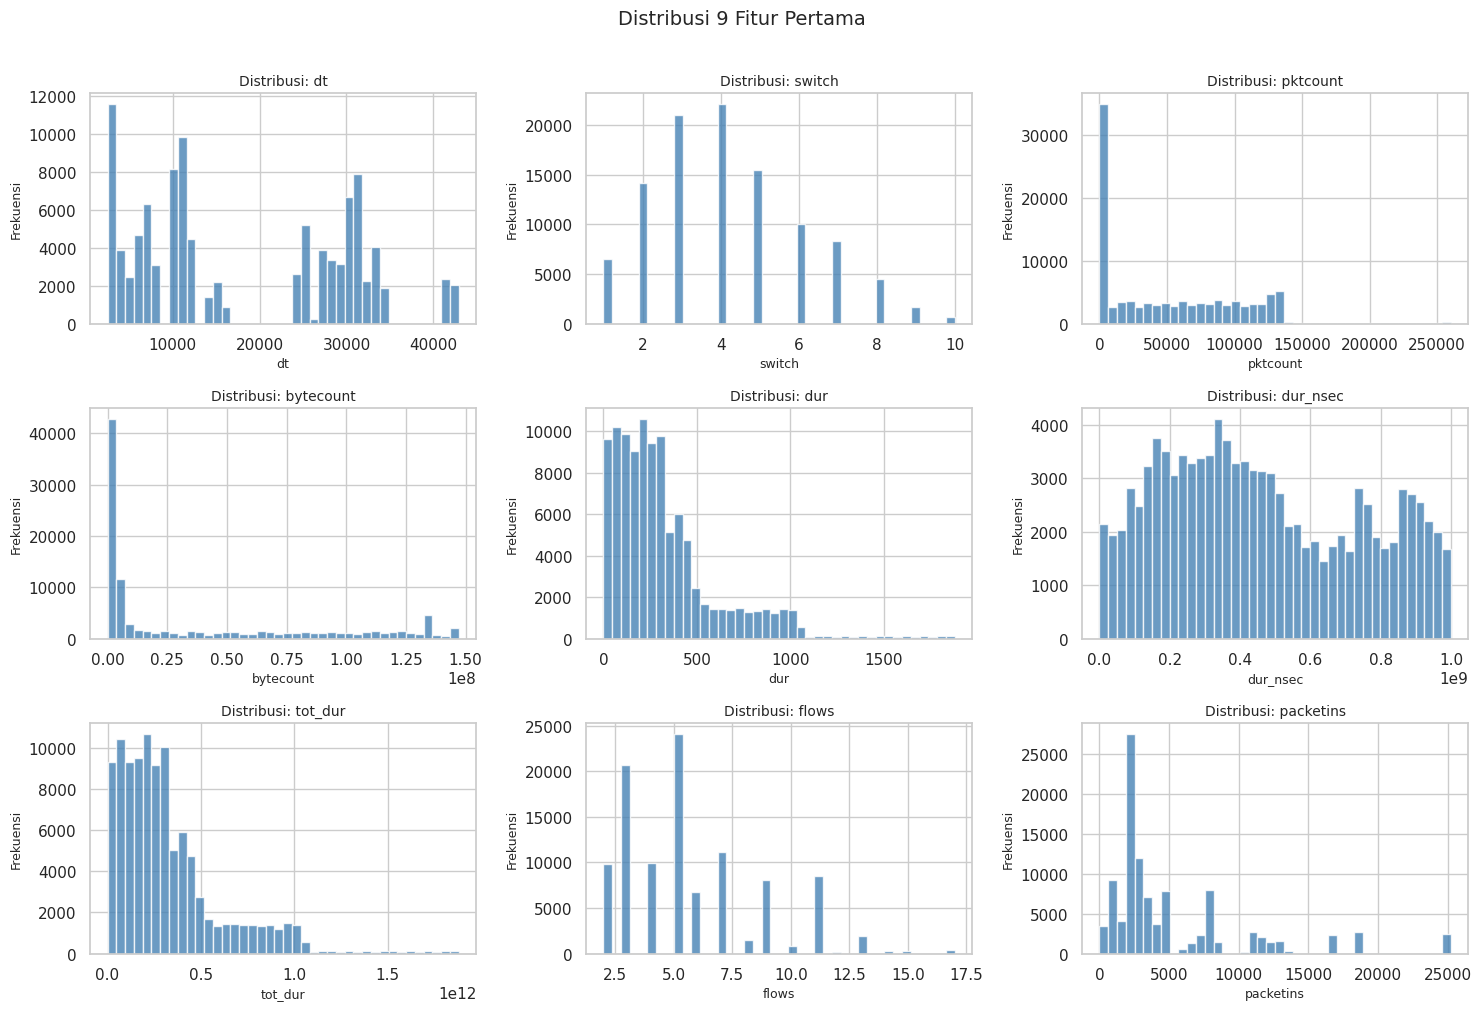

In [216]:
fitur_numerik = df.select_dtypes(include=[np.number]).columns.tolist()
fitur_numerik = [f for f in fitur_numerik if f != 'label']
print(f"\nJumlah fitur numerik (selain label): {len(fitur_numerik)}")

# Pilih 9 fitur pertama untuk divisualisasikan (agar tidak terlalu banyak plot)
fitur_plot = fitur_numerik[:9]
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, fitur in enumerate(fitur_plot):
    axes[i].hist(df[fitur], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribusi: {fitur}', fontsize=10)
    axes[i].set_xlabel(fitur, fontsize=9)
    axes[i].set_ylabel('Frekuensi', fontsize=9)
plt.suptitle('Distribusi 9 Fitur Pertama', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_distribusi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()

## 3d. Boxplot (Deteksi Outlier Visual)

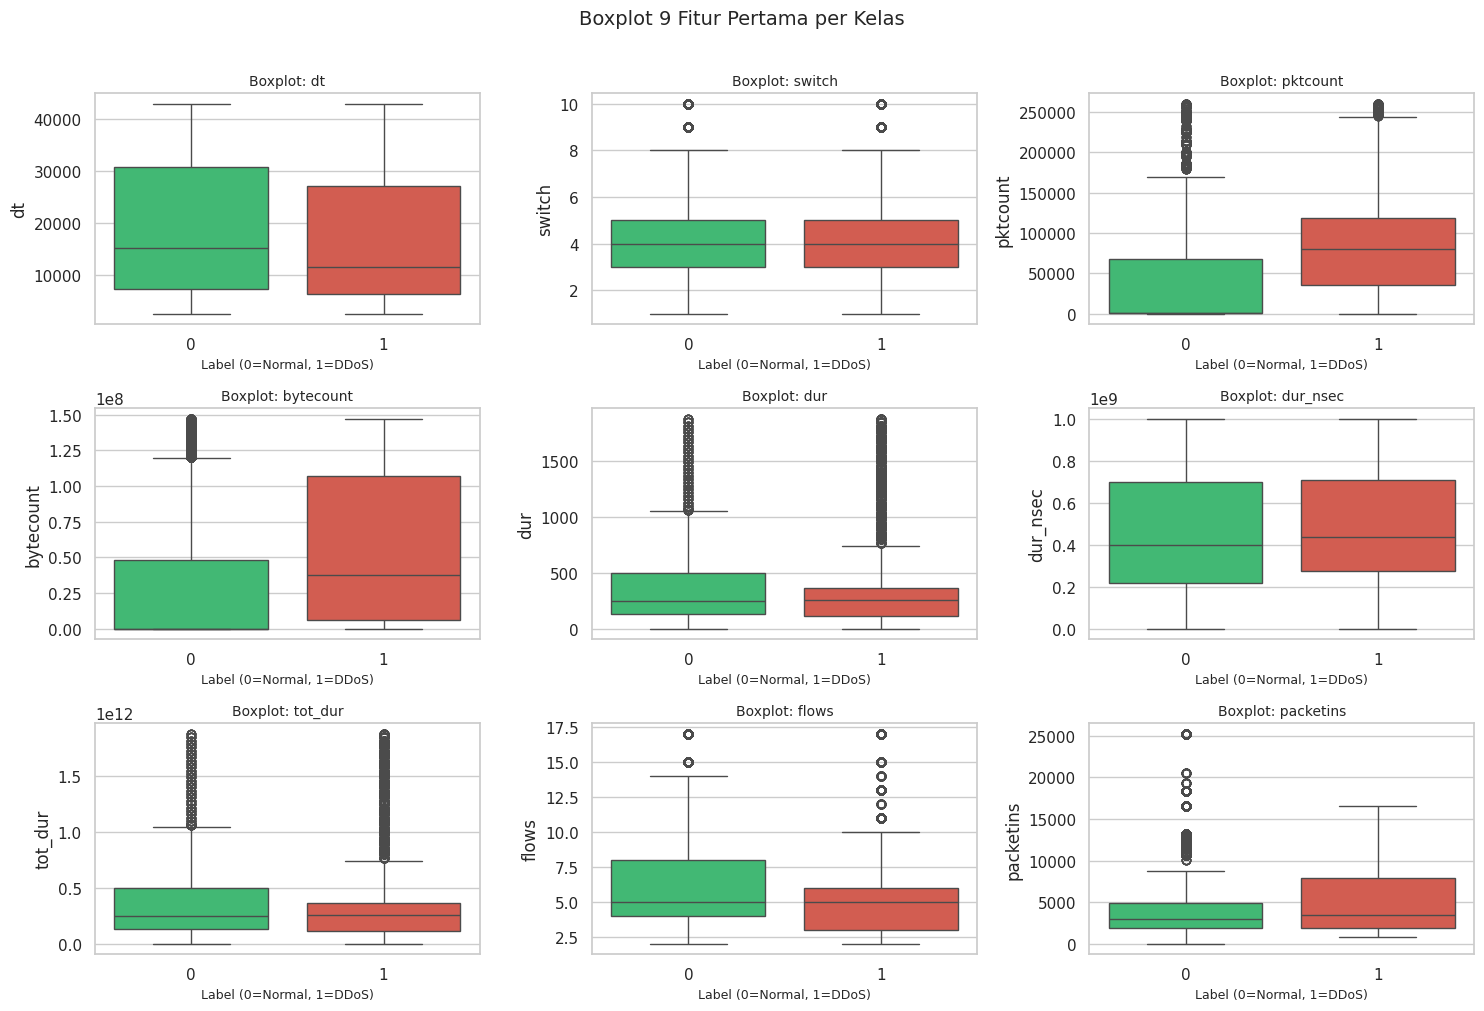

✅ EDA selesai.



In [217]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, fitur in enumerate(fitur_plot):
    sns.boxplot(data=df, x='label', y=fitur,
                palette=['#2ecc71', '#e74c3c'], ax=axes[i])
    axes[i].set_title(f'Boxplot: {fitur}', fontsize=10)
    axes[i].set_xlabel('Label (0=Normal, 1=DDoS)', fontsize=9)
plt.suptitle('Boxplot 9 Fitur Pertama per Kelas', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_boxplot_fitur.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA selesai.\n")

# 4. DATA CLEANING

## 4a. Missing Values

In [218]:
print(f"\n--- Cek Missing Values ---")
missing = df.isnull().sum()
missing_persen = (missing / len(df) * 100).round(2)
df_missing = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)' : missing_persen
})
print(df_missing[df_missing['Jumlah Missing'] > 0])
if missing.sum() == 0:
    print("✅ Tidak ada missing values!")

df_clean = df.dropna().copy()


--- Cek Missing Values ---
          Jumlah Missing  Persentase (%)
rx_kbps              506            0.48
tot_kbps             506            0.48


## 4b. Duplikasi

In [219]:
print(f"\n--- Cek Data Duplikat ---")
n_duplikat = df_clean.duplicated().sum()
print(f"Jumlah baris duplikat: {n_duplikat:,}")

if n_duplikat > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"✅ {n_duplikat:,} baris duplikat dihapus.")
else:
    print("✅ Tidak ada duplikat.")


--- Cek Data Duplikat ---
Jumlah baris duplikat: 5,091
✅ 5,091 baris duplikat dihapus.


## 4c. Hapus Kolom Identitas & Timestamp

In [220]:
# Kolom ini tidak merepresentasikan pola jaringan, hanya identitas unik
# Referensi: Liu et al. (2023) - fitur identitas seperti IP src/dst dibuang
kolom_identitas = ['dt', 'switch', 'src', 'dst']
kolom_ada = [col for col in kolom_identitas if col in df_clean.columns]
if kolom_ada:
    df_clean = df_clean.drop(columns=kolom_ada)
    print(f"\n✅ Kolom identitas dihapus: {kolom_ada}")

# Catat jumlah fitur numerik SETELAH cleaning (bukan dari df raw)
fitur_numerik_setelah_cleaning = [
    f for f in df_clean.select_dtypes(include=[np.number]).columns
    if f != 'label'
]

print(f"\nUkuran setelah cleaning: {df_clean.shape[0]:,} baris, "
      f"{df_clean.shape[1]} kolom")
print(f"Fitur numerik setelah cleaning: {len(fitur_numerik_setelah_cleaning)}")


✅ Kolom identitas dihapus: ['dt', 'switch', 'src', 'dst']

Ukuran setelah cleaning: 98,748 baris, 19 kolom
Fitur numerik setelah cleaning: 17


# 5. TRAIN-TEST SPLIT LEBIH AWAL (STRATIFIED 80:20)

In [221]:
# - Outlier Removal dengan Z-Score menghitung mean & std dari data.
#   Jika dihitung dari SELURUH data (termasuk test), maka keputusan
#   "apakah baris ini outlier" dipengaruhi oleh test set → DATA LEAKAGE.
# - Balancing (undersampling) sebelum split bisa menyebabkan sampling bias:
#   data yang sama bisa masuk ke train dan test secara tidak proporsional.
# - SOLUSI: Split dulu, lalu semua preprocessing hanya pada train set.
#   Test set = cerminan data dunia nyata yang belum pernah dilihat model.
#
# Referensi: Nature Scientific Reports (2025), Géron (2022) Ch.2
# "Stratified train-test split 80% training, 20% testing untuk menjaga
#  distribusi kelas. Semua transformasi fit HANYA pada training set."
print("\n" + "=" * 65)
print("  TAHAP 5: TRAIN-TEST SPLIT (STRATIFIED 80:20)")
print("=" * 65)

X_all = df_clean.drop(columns=['label'])
y_all = df_clean['label']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_all      # Menjaga proporsi kelas di train & test
)

print(f"✅ Split selesai!")
print(f"   Total sampel  : {len(X_all):,}")
print(f"   Data Train    : {len(X_train_raw):,} "
      f"({len(X_train_raw)/len(X_all)*100:.0f}%)")
print(f"   Data Test     : {len(X_test_raw):,} "
      f"({len(X_test_raw)/len(X_all)*100:.0f}%)")
print(f"\n   Distribusi y_train: {dict(y_train.value_counts())}")
print(f"   Distribusi y_test : {dict(y_test.value_counts())}")
print(f"\n⚠️  CATATAN: Test set akan dibiarkan apa adanya (tidak di-outlier-")
print(f"   removal, tidak di-balance) agar evaluasi mencerminkan kondisi nyata.")


  TAHAP 5: TRAIN-TEST SPLIT (STRATIFIED 80:20)
✅ Split selesai!
   Total sampel  : 98,748
   Data Train    : 78,998 (80%)
   Data Test     : 19,750 (20%)

   Distribusi y_train: {0: np.int64(48817), 1: np.int64(30181)}
   Distribusi y_test : {0: np.int64(12205), 1: np.int64(7545)}

⚠️  CATATAN: Test set akan dibiarkan apa adanya (tidak di-outlier-
   removal, tidak di-balance) agar evaluasi mencerminkan kondisi nyata.


# 6. OUTLIER DETECTION & REMOVAL HANYA PADA TRAIN (Z-SCORE)

In [222]:
# Referensi: Géron (2022) & Wine Dataset Paper (infoteks.org/jsikti)
# "Outlier pada atribut numerik dapat mempengaruhi model berbasis jarak
#  seperti KNN secara signifikan. Z-score dihitung HANYA dari training data
#  agar tidak ada informasi test set yang bocor ke proses training."
print("\n" + "=" * 65)
print("  TAHAP 6: OUTLIER REMOVAL HANYA PADA TRAIN (Z-SCORE)")
print("=" * 65)

fitur_num_train = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
print(f"Fitur numerik yang dicek outlier (pada train): {len(fitur_num_train)} kolom")

Z_THRESHOLD = 3

# Z-Score HANYA dihitung dari train set — test set TIDAK DISENTUH
z_scores_train = np.abs(stats.zscore(X_train_raw[fitur_num_train]))
mask_train_bersih = (z_scores_train < Z_THRESHOLD).all(axis=1)

n_outlier_train = (~mask_train_bersih).sum()
print(f"Outlier di train (|Z| > {Z_THRESHOLD}): "
      f"{n_outlier_train:,} baris ({n_outlier_train/len(X_train_raw)*100:.2f}%)")

# Reset index penting agar tidak ada mismatch index saat balancing nanti
X_train_raw = X_train_raw[mask_train_bersih].reset_index(drop=True)
y_train      = y_train[mask_train_bersih].reset_index(drop=True)

print(f"✅ Outlier train dihapus!")
print(f"   Train setelah outlier removal: {len(X_train_raw):,} baris")
print(f"   Test set                     : {len(X_test_raw):,} baris (tidak diubah)")

print(f"\nDistribusi kelas train setelah outlier removal:")
print(y_train.value_counts())


  TAHAP 6: OUTLIER REMOVAL HANYA PADA TRAIN (Z-SCORE)
Fitur numerik yang dicek outlier (pada train): 17 kolom
Outlier di train (|Z| > 3): 10,818 baris (13.69%)
✅ Outlier train dihapus!
   Train setelah outlier removal: 68,180 baris
   Test set                     : 19,750 baris (tidak diubah)

Distribusi kelas train setelah outlier removal:
label
0    42006
1    26174
Name: count, dtype: int64


# 7.  DATA BALANCING HANYA PADA TRAIN (UNDERSAMPLING)

In [223]:
print("\n" + "=" * 65)
print("  TAHAP 7: DATA BALANCING HANYA PADA TRAIN (UNDERSAMPLING)")
print("=" * 65)

print("Distribusi kelas train SEBELUM balancing:")
print(y_train.value_counts())

# Gabungkan X_train dan y_train agar mudah disampling
df_train = X_train_raw.copy()
df_train['label'] = y_train.values

n_tersedia_normal = len(df_train[df_train['label'] == 0])
n_tersedia_ddos   = len(df_train[df_train['label'] == 1])
n_samples         = min(15000, n_tersedia_normal, n_tersedia_ddos)

print(f"\nJumlah sampel tersedia — Normal: {n_tersedia_normal:,} | "
      f"DDoS: {n_tersedia_ddos:,}")
print(f"Jumlah sampel diambil  — {n_samples:,} per kelas "
      f"(total train: {n_samples*2:,})")

df_train_normal = df_train[df_train['label'] == 0].sample(
    n=n_samples, random_state=RANDOM_STATE
)
df_train_ddos = df_train[df_train['label'] == 1].sample(
    n=n_samples, random_state=RANDOM_STATE
)

df_train_balanced = (
    pd.concat([df_train_normal, df_train_ddos])
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

# Pisahkan kembali X dan y dari train yang sudah balanced
X_train_balanced = df_train_balanced.drop(columns=['label'])
y_train_balanced = df_train_balanced['label']

print(f"\nDistribusi kelas train SETELAH balancing:")
print(y_train_balanced.value_counts())
print(f"\nDistribusi kelas test (tidak diubah — mencerminkan kondisi nyata):")
print(y_test.value_counts())
print(f"\n✅ Balancing selesai!")
print(f"   Train: {len(X_train_balanced):,} baris | Test: {len(X_test_raw):,} baris")


  TAHAP 7: DATA BALANCING HANYA PADA TRAIN (UNDERSAMPLING)
Distribusi kelas train SEBELUM balancing:
label
0    42006
1    26174
Name: count, dtype: int64

Jumlah sampel tersedia — Normal: 42,006 | DDoS: 26,174
Jumlah sampel diambil  — 15,000 per kelas (total train: 30,000)

Distribusi kelas train SETELAH balancing:
label
0    15000
1    15000
Name: count, dtype: int64

Distribusi kelas test (tidak diubah — mencerminkan kondisi nyata):
label
0    12205
1     7545
Name: count, dtype: int64

✅ Balancing selesai!
   Train: 30,000 baris | Test: 19,750 baris


# 8. ONE-HOT ENCODING SETELAH SPLIT (ANTI DATA LEAKAGE)

In [224]:
# Referensi: OpenML ML Engineering Lecture (ml-course.github.io)
# "OHE harus fit pada train, lalu reindex ke test untuk menghindari leakage."
print("\n" + "=" * 65)
print("  TAHAP 8: ONE-HOT ENCODING (SETELAH SPLIT)")
print("=" * 65)

if 'Protocol' in X_train_balanced.columns:
    X_train_enc = pd.get_dummies(X_train_balanced, columns=['Protocol'],
                                  drop_first=True, dtype=int)
    X_test_enc  = pd.get_dummies(X_test_raw,       columns=['Protocol'],
                                  drop_first=True, dtype=int)

    # Sejajarkan kolom test ke train (isi 0 jika ada kategori tidak muncul)
    X_test_enc = X_test_enc.reindex(
        columns=X_train_enc.columns, fill_value=0
    )
    print(f"✅ One-Hot Encoding 'Protocol' selesai!")
    print(f"   Kolom setelah OHE: {X_train_enc.shape[1]}")
else:
    X_train_enc = X_train_balanced.copy()
    X_test_enc  = X_test_raw.copy()
    print("ℹ️  Kolom 'Protocol' tidak ditemukan. Skip OHE.")

# Simpan nama kolom setelah OHE (dibutuhkan saat prediksi di Linux)
NAMA_KOLOM_FITUR = X_train_enc.columns.tolist()
print(f"   Total fitur masuk scaling: {len(NAMA_KOLOM_FITUR)}")


  TAHAP 8: ONE-HOT ENCODING (SETELAH SPLIT)
✅ One-Hot Encoding 'Protocol' selesai!
   Kolom setelah OHE: 19
   Total fitur masuk scaling: 19


# 9. FEATURE SCALING (STANDARD SCALER)

In [225]:
# Referensi: Géron (2022) & Sensors MDPI (2023)
# "Feature scaling sangat krusial untuk KNN karena algoritma ini menghitung
#  jarak. Scaler di-fit HANYA pada train, lalu transform keduanya."
print("\n" + "=" * 65)
print("  TAHAP 9: FEATURE SCALING (STANDARD SCALER)")
print("=" * 65)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)   # fit + transform TRAIN
X_test_scaled  = scaler.transform(X_test_enc)        # transform TEST saja

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=NAMA_KOLOM_FITUR)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=NAMA_KOLOM_FITUR)

print(f"✅ Scaling selesai!")
print(f"   Scaler di-fit HANYA pada data train (anti data leakage)")
print(f"   Mean train (sampel 3 kolom pertama): "
      f"{X_train_scaled[:, :3].mean(axis=0).round(4)}")


  TAHAP 9: FEATURE SCALING (STANDARD SCALER)
✅ Scaling selesai!
   Scaler di-fit HANYA pada data train (anti data leakage)
   Mean train (sampel 3 kolom pertama): [-0.  0. -0.]


# 10. FEATURE SELECTION

## 10a. Hapus Fitur yang Sangat Berkorelasi (Multikolinearitas)


[10a] Analisis Korelasi — Hapus Fitur Redundan (dari train)
      Threshold: korelasi > 0.95 dianggap redundan

Fitur dengan korelasi > 0.95: 2 fitur
Fitur yang dihapus: ['tot_dur', 'pktrate']
Fitur tersisa setelah hapus multikolinearitas: 17


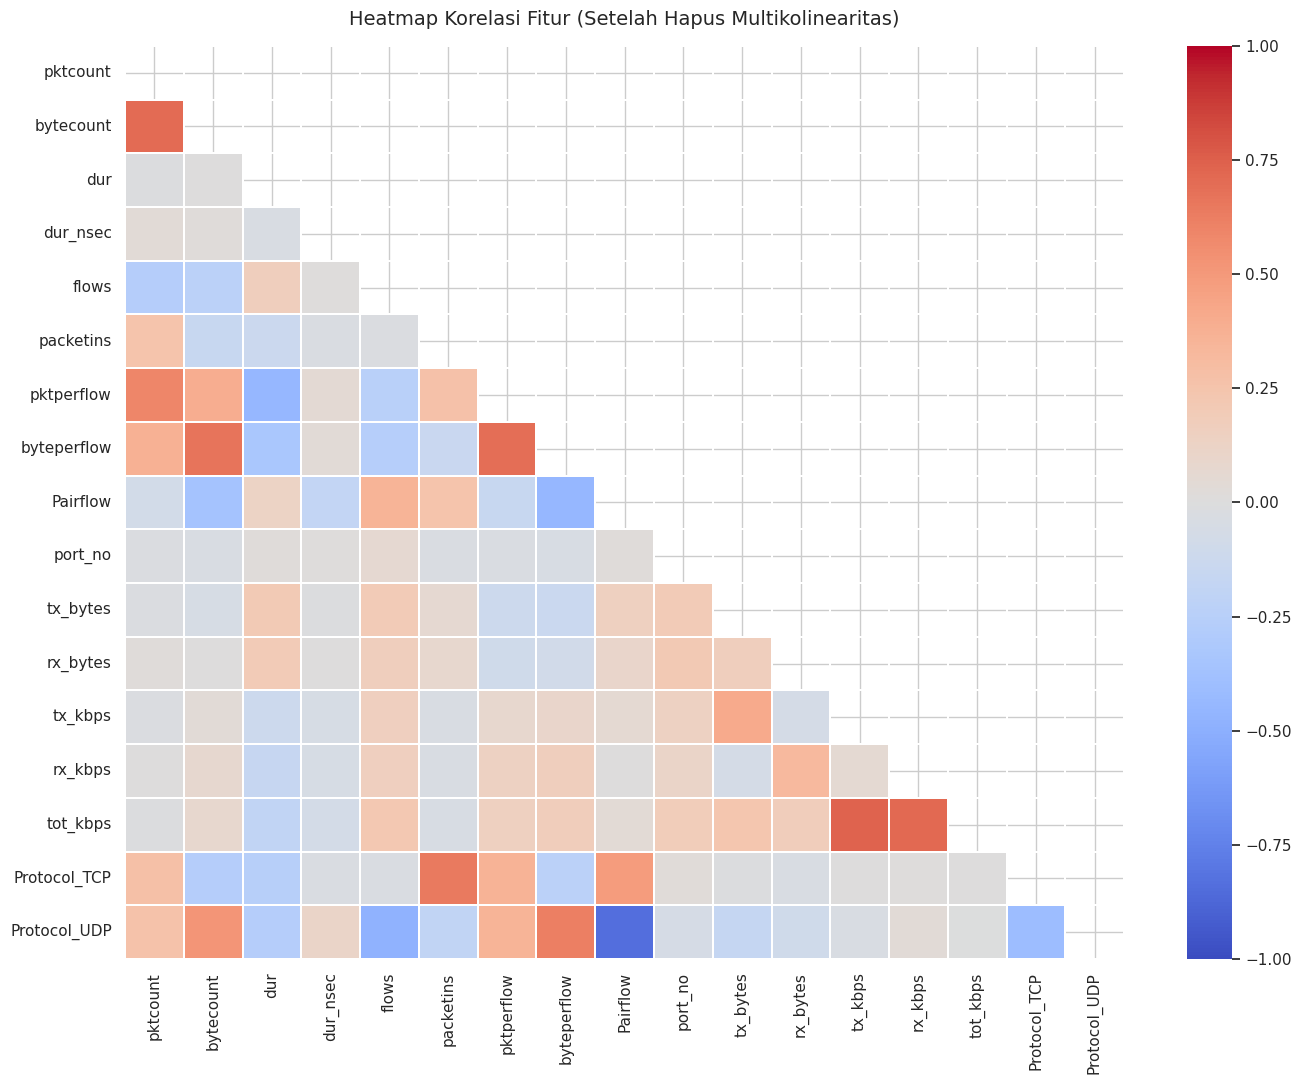

In [226]:
# Matriks korelasi dihitung dari TRAIN saja (anti leakage)
print("\n[10a] Analisis Korelasi — Hapus Fitur Redundan (dari train)")
print("      Threshold: korelasi > 0.95 dianggap redundan\n")

corr_matrix   = X_train_scaled_df.corr().abs()
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

KORELASI_THRESHOLD = 0.95
kolom_hapus_korelasi = [
    col for col in upper_triangle.columns
    if any(upper_triangle[col] > KORELASI_THRESHOLD)
]

print(f"Fitur dengan korelasi > {KORELASI_THRESHOLD}: "
      f"{len(kolom_hapus_korelasi)} fitur")
if kolom_hapus_korelasi:
    print(f"Fitur yang dihapus: {kolom_hapus_korelasi}")

X_train_nocorr = X_train_scaled_df.drop(columns=kolom_hapus_korelasi, errors='ignore')
X_test_nocorr  = X_test_scaled_df.drop(columns=kolom_hapus_korelasi,  errors='ignore')

# [FIX-5] Simpan nama kolom SETELAH hapus korelasi — ini adalah urutan
# kolom yang akan dimasukkan ke selector. Wajib diexport untuk produksi.
NAMA_KOLOM_NOCORR = X_train_nocorr.columns.tolist()

print(f"Fitur tersisa setelah hapus multikolinearitas: "
      f"{X_train_nocorr.shape[1]}")

# Visualisasi heatmap korelasi
plt.figure(figsize=(14, 11))
corr_final = X_train_nocorr.corr()
mask = np.triu(np.ones_like(corr_final, dtype=bool))
sns.heatmap(corr_final, mask=mask, annot=False, cmap='coolwarm',
            linewidths=0.3, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Fitur (Setelah Hapus Multikolinearitas)',
          fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('feature_heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

## 10b. SelectKBest — Pilih K Fitur Terbaik (ANOVA F-test)


[10b] SelectKBest (ANOVA F-test) — fit hanya pada train
Fitur tersedia    : 17
Fitur akan dipilih: 10 (≈60% dari tersedia)

✅ Fitur terpilih (10 fitur):
          Fitur   Skor F
0      pktcount  9383.67
1     bytecount  2752.67
2    pktperflow  2215.65
3           dur  1583.77
4         flows  1225.16
5  Protocol_TCP  1191.55
6  Protocol_UDP  1085.87
7     packetins   662.73
8      tx_bytes   167.15
9      rx_bytes   107.51


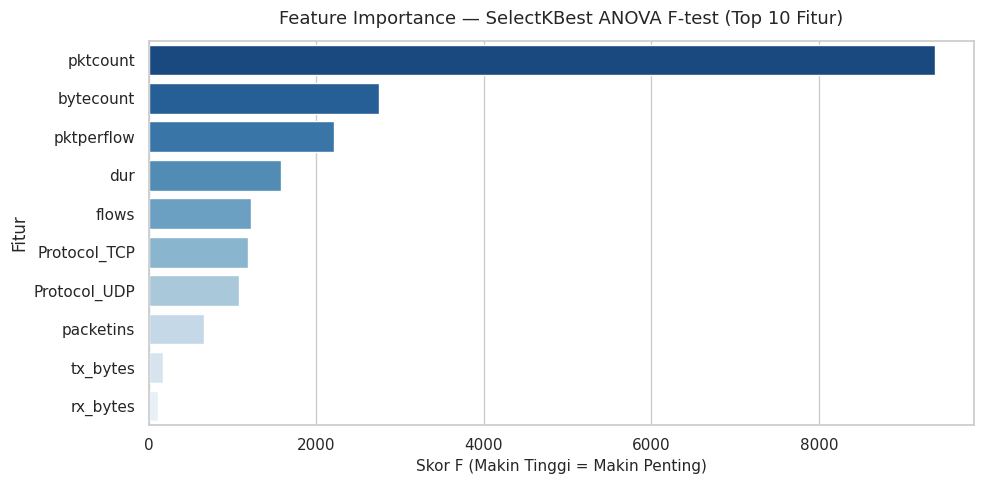


Ukuran X_train setelah feature selection: (30000, 10)
Ukuran X_test  setelah feature selection: (19750, 10)


In [227]:
# fit HANYA pada train (dengan y_train_balanced), transform pada keduanya
print("\n[10b] SelectKBest (ANOVA F-test) — fit hanya pada train")

fitur_tersedia = X_train_nocorr.shape[1]
N_FITUR_PILIH  = max(5, min(int(fitur_tersedia * 0.6), fitur_tersedia))
print(f"Fitur tersedia    : {fitur_tersedia}")
print(f"Fitur akan dipilih: {N_FITUR_PILIH} (≈60% dari tersedia)")

selector = SelectKBest(score_func=f_classif, k=N_FITUR_PILIH)

# fit_transform pada train, transform pada test (anti leakage)
X_train_selected = selector.fit_transform(X_train_nocorr, y_train_balanced)
X_test_selected  = selector.transform(X_test_nocorr)

fitur_terpilih = X_train_nocorr.columns[selector.get_support()].tolist()
skor_fitur     = selector.scores_[selector.get_support()]

df_skor_fitur = pd.DataFrame({
    'Fitur'  : fitur_terpilih,
    'Skor F' : skor_fitur.round(2)
}).sort_values('Skor F', ascending=False).reset_index(drop=True)

print(f"\n✅ Fitur terpilih ({N_FITUR_PILIH} fitur):")
print(df_skor_fitur.to_string())

# Visualisasi skor fitur
plt.figure(figsize=(10, max(5, N_FITUR_PILIH * 0.4)))
sns.barplot(data=df_skor_fitur, x='Skor F', y='Fitur', palette='Blues_r')
plt.title(f'Feature Importance — SelectKBest ANOVA F-test '
          f'(Top {N_FITUR_PILIH} Fitur)',
          fontsize=13, pad=12)
plt.xlabel('Skor F (Makin Tinggi = Makin Penting)', fontsize=11)
plt.tight_layout()
plt.savefig('feature_importance_selectkbest.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nUkuran X_train setelah feature selection: {X_train_selected.shape}")
print(f"Ukuran X_test  setelah feature selection: {X_test_selected.shape}")

# 11. HYPERPARAMETER TUNING (GRIDSEARCHCV + 5-FOLD CV)


  TAHAP 11: HYPERPARAMETER TUNING (GRIDSEARCHCV)
⏳ Proses ini membutuhkan beberapa menit. Mohon tunggu...

Parameter yang diuji:
  n_neighbors: [3, 5, 7, 9, 11, 13, 15]
  weights: ['uniform', 'distance']
  metric: ['euclidean', 'manhattan']

Total kombinasi: 28
Fitting 5 folds for each of 28 candidates, totalling 140 fits

✅ HYPERPARAMETER TUNING SELESAI!
Parameter Terbaik  : {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
F1 Score CV Terbaik: 98.3202%

--- Perbandingan F1 Score per Nilai K ---
 K  F1_Score
 3  0.983202
 5  0.983131
 7  0.983132
 9  0.982553
11  0.982632
13  0.981445
15  0.980641


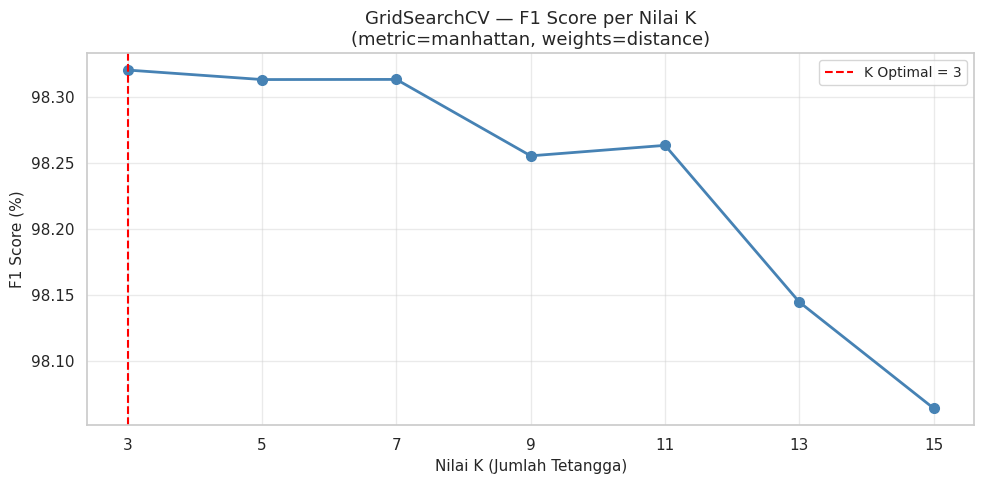

In [228]:
# Referensi: Scientific Reports (2025), NumberAnalytics
print("\n" + "=" * 65)
print("  TAHAP 11: HYPERPARAMETER TUNING (GRIDSEARCHCV)")
print("=" * 65)
print("⏳ Proses ini membutuhkan beberapa menit. Mohon tunggu...\n")

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan']
}

print("Parameter yang diuji:")
for k, v in param_grid.items():
    print(f"  {k}: {v}")
total_kombinasi = (len(param_grid['n_neighbors'])
                   * len(param_grid['weights'])
                   * len(param_grid['metric']))
print(f"\nTotal kombinasi: {total_kombinasi}")

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator  = KNeighborsClassifier(),
    param_grid = param_grid,
    cv         = cv_strategy,
    scoring    = 'f1',
    n_jobs     = -1,
    verbose    = 1
)

# Tuning dilakukan pada X_train_selected dan y_train_balanced
grid_search.fit(X_train_selected, y_train_balanced)

best_params   = grid_search.best_params_
best_cv_score = grid_search.best_score_

print(f"\n{'='*50}")
print(f"✅ HYPERPARAMETER TUNING SELESAI!")
print(f"{'='*50}")
print(f"Parameter Terbaik  : {best_params}")
print(f"F1 Score CV Terbaik: {best_cv_score * 100:.4f}%")

# Visualisasi hasil GridSearch
hasil_cv = pd.DataFrame(grid_search.cv_results_)
k_scores = (hasil_cv.groupby('param_n_neighbors')['mean_test_score']
            .max()
            .reset_index())
k_scores.columns = ['K', 'F1_Score']
print("\n--- Perbandingan F1 Score per Nilai K ---")
print(k_scores.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.plot(k_scores['K'], k_scores['F1_Score'] * 100,
         marker='o', color='steelblue', linewidth=2, markersize=7)
plt.axvline(x=best_params['n_neighbors'], color='red',
            linestyle='--', label=f"K Optimal = {best_params['n_neighbors']}")
plt.title('GridSearchCV — F1 Score per Nilai K\n'
          f"(metric={best_params['metric']}, "
          f"weights={best_params['weights']})",
          fontsize=13)
plt.xlabel('Nilai K (Jumlah Tetangga)', fontsize=11)
plt.ylabel('F1 Score (%)', fontsize=11)
plt.xticks(k_scores['K'])
plt.legend(fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('hyperparameter_tuning_k.png', dpi=150, bbox_inches='tight')
plt.show()

# 12. PELATIHAN MODEL KNN DENGAN PARAMETER OPTIMAL

In [229]:
print("\n" + "=" * 65)
print("  TAHAP 12: PELATIHAN MODEL KNN (PARAMETER OPTIMAL)")
print("=" * 65)

knn_final = KNeighborsClassifier(
    n_neighbors = best_params['n_neighbors'],
    weights     = best_params['weights'],
    metric      = best_params['metric']
)

knn_final.fit(X_train_selected, y_train_balanced)

print(f"✅ Model KNN berhasil dilatih!")
print(f"   K (n_neighbors) : {best_params['n_neighbors']}")
print(f"   Weights          : {best_params['weights']}")
print(f"   Distance Metric  : {best_params['metric']}")
print(f"   Jumlah fitur     : {X_train_selected.shape[1]}")
print(f"   Jumlah data train: {X_train_selected.shape[0]:,}")


  TAHAP 12: PELATIHAN MODEL KNN (PARAMETER OPTIMAL)
✅ Model KNN berhasil dilatih!
   K (n_neighbors) : 3
   Weights          : distance
   Distance Metric  : manhattan
   Jumlah fitur     : 10
   Jumlah data train: 30,000


# 13. EVALUASI MODEL

In [230]:
# Test set murni — tidak pernah disentuh scaler/selector dalam proses fit,
# tidak di-balance, tidak di-outlier-removal → evaluasi paling valid.
print("\n" + "=" * 65)
print("  TAHAP 13: EVALUASI MODEL")
print("=" * 65)

y_pred      = knn_final.predict(X_test_selected)
y_pred_prob = knn_final.predict_proba(X_test_selected)[:, 1]

akurasi = accuracy_score(y_test, y_pred)
presisi = precision_score(y_test, y_pred, zero_division=0)
recall  = recall_score(y_test, y_pred, zero_division=0)
f1      = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"\n{'='*50}")
print(f"  🎉 HASIL EVALUASI MODEL KNN  🎉")
print(f"{'='*50}")
print(f"  Accuracy   : {akurasi  * 100:.4f}%")
print(f"  Precision  : {presisi  * 100:.4f}%")
print(f"  Recall     : {recall   * 100:.4f}%")
print(f"  F1-Score   : {f1       * 100:.4f}%")
print(f"  ROC-AUC    : {roc_auc  * 100:.4f}%")
print(f"{'='*50}")

print(f"\n--- Classification Report ---")
print(classification_report(
    y_test, y_pred,
    target_names=['Normal (0)', 'DDoS (1)'],
    zero_division=0
))

# 5-Fold Cross-Validation pada model final (hanya pada train)
print("\n--- 5-Fold Cross-Validation (Verifikasi Generalisasi) ---")
cv_scores = cross_val_score(
    knn_final, X_train_selected, y_train_balanced,
    cv=cv_strategy, scoring='f1', n_jobs=-1
)
print(f"F1 Score per fold: {np.round(cv_scores * 100, 4)}")
print(f"Rata-rata F1     : {cv_scores.mean() * 100:.4f}%")
print(f"Standar Deviasi  : {cv_scores.std()  * 100:.4f}%")

if cv_scores.std() < 0.02:
    print("✅ Standar deviasi kecil → Model STABIL dan tidak overfit")
else:
    print("⚠️  Standar deviasi besar → Perlu dicek potensi overfitting")


  TAHAP 13: EVALUASI MODEL

  🎉 HASIL EVALUASI MODEL KNN  🎉
  Accuracy   : 97.5241%
  Precision  : 95.2888%
  Recall     : 98.3830%
  F1-Score   : 96.8112%
  ROC-AUC    : 99.0175%

--- Classification Report ---
              precision    recall  f1-score   support

  Normal (0)       0.99      0.97      0.98     12205
    DDoS (1)       0.95      0.98      0.97      7545

    accuracy                           0.98     19750
   macro avg       0.97      0.98      0.97     19750
weighted avg       0.98      0.98      0.98     19750


--- 5-Fold Cross-Validation (Verifikasi Generalisasi) ---
F1 Score per fold: [98.503  98.1082 98.5223 97.9429 98.5248]
Rata-rata F1     : 98.3202%
Standar Deviasi  : 0.2463%
✅ Standar deviasi kecil → Model STABIL dan tidak overfit


# 14. VISUALISASI HASIL EVALUASI

## 14a. Confusion Matrix
## 14b. ROC Curve
## 14c. Ringkasan Metrik


  TAHAP 14: VISUALISASI HASIL EVALUASI

--- Detail Confusion Matrix ---
  True Negative  (TN) : 11,838  — Normal terdeteksi Normal ✅
  False Positive (FP) : 367  — Normal salah terdeteksi DDoS ❌
  False Negative (FN) : 122  — DDoS lolos tidak terdeteksi ❌
  True Positive  (TP) : 7,423  — DDoS terdeteksi DDoS ✅


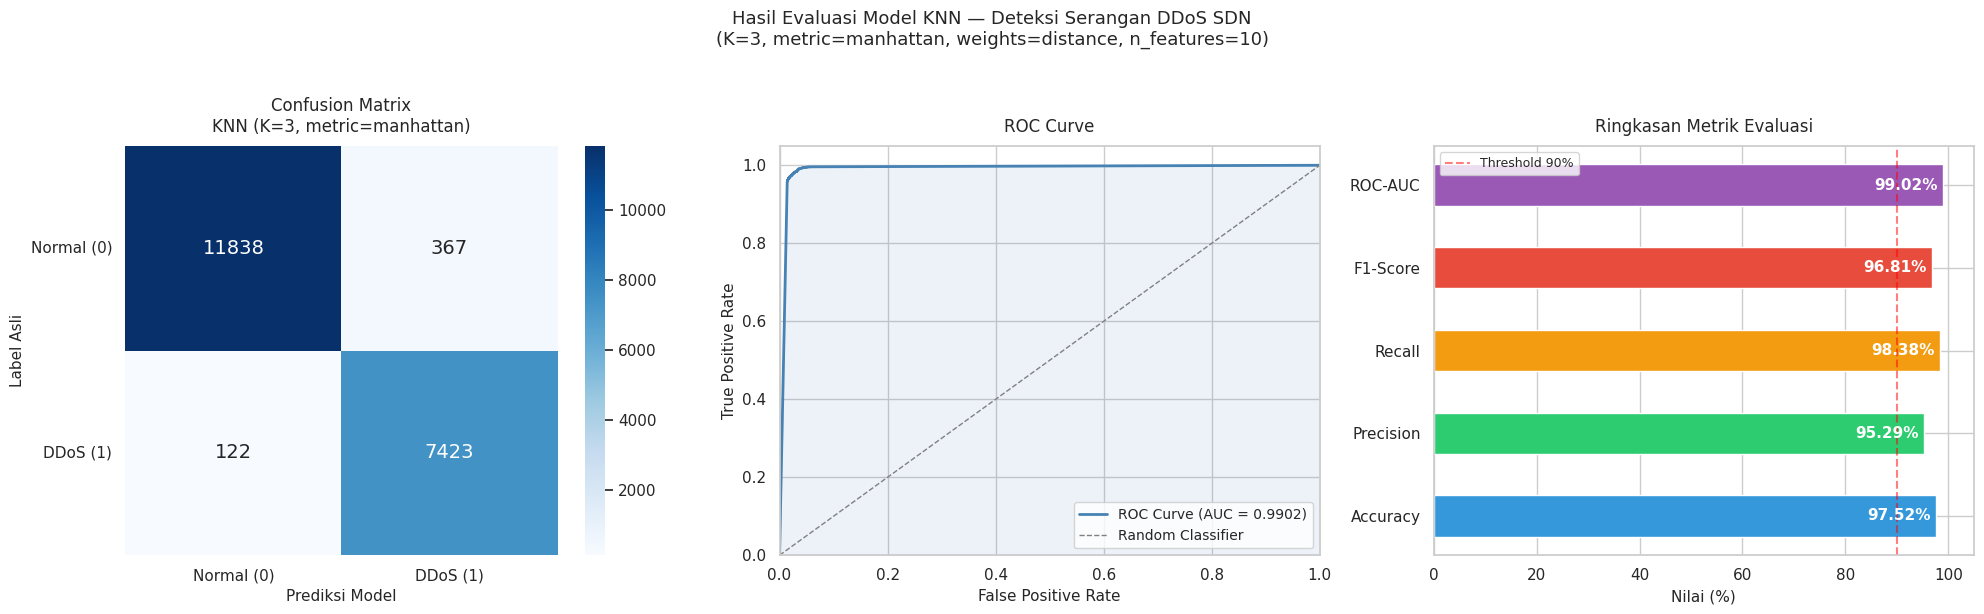

In [231]:
print("\n" + "=" * 65)
print("  TAHAP 14: VISUALISASI HASIL EVALUASI")
print("=" * 65)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- 14a. Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            annot_kws={"size": 14}, ax=axes[0])
axes[0].set_title(
    f'Confusion Matrix\nKNN (K={best_params["n_neighbors"]}, '
    f'metric={best_params["metric"]})',
    fontsize=12, pad=10
)
axes[0].set_xlabel('Prediksi Model', fontsize=11)
axes[0].set_ylabel('Label Asli', fontsize=11)
axes[0].set_xticklabels(['Normal (0)', 'DDoS (1)'])
axes[0].set_yticklabels(['Normal (0)', 'DDoS (1)'], rotation=0)

tn, fp, fn, tp = cm.ravel()
print(f"\n--- Detail Confusion Matrix ---")
print(f"  True Negative  (TN) : {tn:,}  — Normal terdeteksi Normal ✅")
print(f"  False Positive (FP) : {fp:,}  — Normal salah terdeteksi DDoS ❌")
print(f"  False Negative (FN) : {fn:,}  — DDoS lolos tidak terdeteksi ❌")
print(f"  True Positive  (TP) : {tp:,}  — DDoS terdeteksi DDoS ✅")

# --- 14b. ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1,
             linestyle='--', label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_title('ROC Curve', fontsize=12, pad=10)
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])

# --- 14c. Ringkasan Metrik ---
metrik_nama  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrik_nilai = [akurasi, presisi, recall, f1, roc_auc]
warna        = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']

bars = axes[2].barh(metrik_nama, [v * 100 for v in metrik_nilai],
                     color=warna, edgecolor='white', height=0.5)
for bar, val in zip(bars, metrik_nilai):
    axes[2].text(bar.get_width() - 1, bar.get_y() + bar.get_height() / 2,
                 f'{val*100:.2f}%', va='center', ha='right',
                 color='white', fontweight='bold', fontsize=11)
axes[2].set_title('Ringkasan Metrik Evaluasi', fontsize=12, pad=10)
axes[2].set_xlabel('Nilai (%)', fontsize=11)
axes[2].set_xlim([0, 105])
axes[2].axvline(x=90, color='red', linestyle='--',
                alpha=0.5, label='Threshold 90%')
axes[2].legend(fontsize=9)

plt.suptitle(
    f'Hasil Evaluasi Model KNN — Deteksi Serangan DDoS SDN\n'
    f'(K={best_params["n_neighbors"]}, '
    f'metric={best_params["metric"]}, '
    f'weights={best_params["weights"]}, '
    f'n_features={X_train_selected.shape[1]})',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig('hasil_evaluasi_knn.png', dpi=150, bbox_inches='tight')
plt.show()

## 14d. Cross-Validation Score per Fold

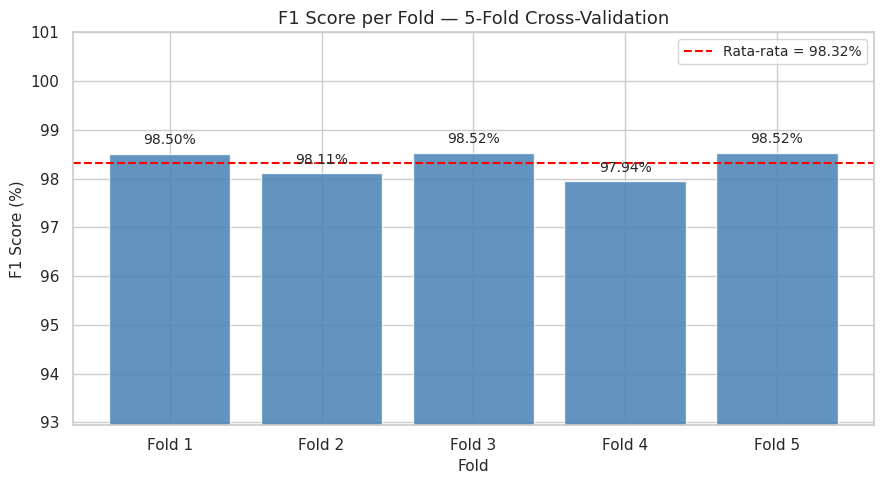


✅ Semua visualisasi tersimpan.


In [232]:
# --- 14d. Cross-Validation Score per Fold ---
plt.figure(figsize=(9, 5))
folds = [f'Fold {i+1}' for i in range(len(cv_scores))]
bars  = plt.bar(folds, cv_scores * 100, color='steelblue',
                edgecolor='white', alpha=0.85)
plt.axhline(y=cv_scores.mean() * 100, color='red', linestyle='--',
            label=f'Rata-rata = {cv_scores.mean()*100:.2f}%')
for bar, val in zip(bars, cv_scores):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.2,
             f'{val*100:.2f}%', ha='center', fontsize=10)
plt.title('F1 Score per Fold — 5-Fold Cross-Validation', fontsize=13)
plt.xlabel('Fold', fontsize=11)
plt.ylabel('F1 Score (%)', fontsize=11)
plt.ylim([max(0, cv_scores.min() * 100 - 5), 101])
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('cross_validation_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Semua visualisasi tersimpan.")

# 15. EXPORT MODEL, SCALER, SELECTOR, DAN KONFIGURASI

In [233]:
# ==========================================================================
# TAHAP 15: EXPORT MODEL, SCALER, SELECTOR, DAN KONFIGURASI
# ==========================================================================
# File yang WAJIB dibawa ke Linux (sekarang 8 file .pkl):
#   1. model_knn_ddos.pkl          — Model KNN yang sudah dilatih
#   2. scaler_ddos.pkl             — StandardScaler (fit dari train)
#   3. selector_ddos.pkl           — SelectKBest (fit dari train)
#   4. feature_columns.pkl         — Kolom setelah OHE (input ke scaler)
#   5. kolom_hapus_korelasi.pkl    — [FIX-4] Kolom yg dihapus di tahap korelasi
#   6. kolom_nocorr.pkl            — [FIX-5] Kolom input ke selector (urutan!)
#   7. fitur_terpilih.pkl          — Nama fitur setelah seleksi (untuk referensi)
#   8. konfigurasi_model.pkl       — Ringkasan semua parameter & metrik
#
# URUTAN PIPELINE DI SERVER.PY (LINUX):
#   raw_data
#     → reindex ke NAMA_KOLOM_FITUR (feature_columns.pkl)
#     → scaler.transform()          (scaler_ddos.pkl)
#     → drop kolom_hapus_korelasi   (kolom_hapus_korelasi.pkl)
#     → reindex ke NAMA_KOLOM_NOCORR (kolom_nocorr.pkl)  ← PENTING: urutan!
#     → selector.transform()         (selector_ddos.pkl)
#     → knn.predict()                (model_knn_ddos.pkl)
print("\n" + "=" * 65)
print("  TAHAP 15: EXPORT MODEL & KONFIGURASI")
print("=" * 65)

konfigurasi = {
    'best_params'          : best_params,
    'n_fitur_input'        : len(NAMA_KOLOM_FITUR),
    'n_fitur_setelah_fs'   : X_train_selected.shape[1],
    'fitur_terpilih'       : fitur_terpilih,
    'kolom_hapus_korelasi' : kolom_hapus_korelasi,
    'nama_kolom_fitur'     : NAMA_KOLOM_FITUR,       # setelah OHE
    'nama_kolom_nocorr'    : NAMA_KOLOM_NOCORR,      # setelah hapus korelasi
    'metrics_test'         : {
        'accuracy' : round(akurasi, 6),
        'precision': round(presisi, 6),
        'recall'   : round(recall,  6),
        'f1_score' : round(f1,      6),
        'roc_auc'  : round(roc_auc, 6)
    },
    'cv_f1_mean'          : round(cv_scores.mean(), 6),
    'cv_f1_std'           : round(cv_scores.std(),  6),
    'random_state'        : RANDOM_STATE,
    'n_samples_per_class' : n_samples,
    # Catatan metodologi untuk reproduktibilitas
    'metodologi_notes'    : {
        'outlier_removal' : 'Dilakukan HANYA pada train set (post-split, anti leakage)',
        'balancing'       : 'Dilakukan HANYA pada train set (post-split, anti leakage)',
        'scaler_fit'      : 'Fit HANYA pada train set',
        'selector_fit'    : 'Fit HANYA pada train set',
        'test_set'        : 'Tidak di-outlier-removal, tidak di-balance — evaluasi murni'
    }
}

# Export semua file (8 file .pkl)
joblib.dump(knn_final,             'model_knn_ddos.pkl')
joblib.dump(scaler,                'scaler_ddos.pkl')
joblib.dump(selector,              'selector_ddos.pkl')
joblib.dump(NAMA_KOLOM_FITUR,      'feature_columns.pkl')
joblib.dump(kolom_hapus_korelasi,  'kolom_hapus_korelasi.pkl')  # [FIX-4]
joblib.dump(NAMA_KOLOM_NOCORR,     'kolom_nocorr.pkl')          # [FIX-5]
joblib.dump(fitur_terpilih,        'fitur_terpilih.pkl')
joblib.dump(konfigurasi,           'konfigurasi_model.pkl')

print("\n✅ Semua file berhasil disimpan (8 file):")
print("   📦 model_knn_ddos.pkl          — Model KNN terlatih")
print("   📦 scaler_ddos.pkl             — StandardScaler")
print("   📦 selector_ddos.pkl           — Feature Selector (SelectKBest)")
print("   📦 feature_columns.pkl         — Kolom setelah OHE (input scaler)")
print("   📦 kolom_hapus_korelasi.pkl    — [FIX-4] Kolom dihapus (korelasi)")
print("   📦 kolom_nocorr.pkl            — [FIX-5] Kolom input selector")
print("   📦 fitur_terpilih.pkl          — Nama fitur setelah seleksi")
print("   📦 konfigurasi_model.pkl       — Ringkasan parameter & metrik")


  TAHAP 15: EXPORT MODEL & KONFIGURASI

✅ Semua file berhasil disimpan (8 file):
   📦 model_knn_ddos.pkl          — Model KNN terlatih
   📦 scaler_ddos.pkl             — StandardScaler
   📦 selector_ddos.pkl           — Feature Selector (SelectKBest)
   📦 feature_columns.pkl         — Kolom setelah OHE (input scaler)
   📦 kolom_hapus_korelasi.pkl    — [FIX-4] Kolom dihapus (korelasi)
   📦 kolom_nocorr.pkl            — [FIX-5] Kolom input selector
   📦 fitur_terpilih.pkl          — Nama fitur setelah seleksi
   📦 konfigurasi_model.pkl       — Ringkasan parameter & metrik
